# 🔍 Financial Due Diligence Assistant
## Multi-Agent System using LangGraph + Groq + Tavily

---

### 🏗️ Architecture: Supervisor Pattern (Manager → Workers)

```
         Supervisor
        /     |     \
  Data Agent  News Agent  Writer Agent
```

**Flow:**
```
User Query → Supervisor → Data Agent → Supervisor → News Agent → Supervisor → Writer Agent → END
```

**What each agent does:**
| Agent | Role | Tools Used |
|-------|------|------------|
| Data Agent | Pulls financial metrics from Yahoo Finance | `yfinance` |
| News Agent | Scans web for news & red flags | `Tavily Search` |
| Writer Agent | Synthesizes everything into investment memo | `Groq LLM` |
| Supervisor | Decides who runs next | Rule-based logic |

---

### Step 0: Loading Environment & Liabraries

In [1]:
from dotenv import load_dotenv
load_dotenv()
import os

In [ ]:
# pydantic: For structured data validation
from pydantic import BaseModel, Field

# LangChain components for prompts and parsing
from langchain_core.prompts import PromptTemplate
from langchain_core.output_parsers import StrOutputParser
from langchain_core.output_parsers import PydanticOutputParser

# LangChain message types
from langchain_core.messages import BaseMessage, HumanMessage, AIMessage

# LangChain runnable
from langchain_core.runnables import RunnablePassthrough

# LangGraph
from langgraph.graph import StateGraph, END

c:\Users\HP\anaconda3\envs\fresh_env\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Step 1: Loading/Initializing LLM

In [ ]:
from langchain_groq import ChatGroq

# Groq automatically reads GROQ_API_KEY from environment variables

model = ChatGroq(
    model="openai/gpt-oss-120b",   # or llama-3.3-70b-versatile
    temperature=0.7
)

llm = model

In [ ]:
# ---- TEST ----
try:
    response = llm.invoke("Say hello in one sentence.")
    print("✅ Groq LLM initialized successfully")
    print("Response:", response.content)

except Exception as e:
    print("❌ Groq LLM initialization failed")
    print(e)

✅ Groq LLM initialized successfully
Response: Hello! Hope your day is off to a wonderful start.


## 📋 Step 2 — Shared State Definition

**Concept:** In LangGraph, all agents communicate through a single shared `State` object.
Think of it as a **whiteboard** — every agent can read from it and write to it.

```
State (whiteboard):
┌─────────────────────────────────┐
│ company_name   = "Tesla"        │  ← set by user at start
│ next_agent     = "data_agent"   │  ← written by Supervisor
│ financial_data = "..."          │  ← written by Data Agent
│ news_data      = "..."          │  ← written by News Agent
│ investment_memo = "..."         │  ← written by Writer Agent
│ messages       = [...]          │  ← running log
└─────────────────────────────────┘
```

In [ ]:
from typing import TypedDict, Optional


class AgentState(TypedDict):
    """
    The single source of truth shared between all agents.

    Every field starts as None and gets filled in as agents run.
    LangGraph passes this state into every node function automatically.
    """

    # --- Input from user ---
    company_name: str           # e.g., "Tesla", "Apple"

    # --- Supervisor control ---
    next_agent: str             # "data_agent" | "news_agent" | "writer_agent" | "END"

    # --- Agent outputs (filled in as pipeline progresses) ---
    financial_data: Optional[str]    # Data Agent writes here
    news_data: Optional[str]         # News Agent writes here
    investment_memo: Optional[str]   # Writer Agent writes here

    # --- Conversation history ---
    messages: list              # Running log of what each agent did


print("✅ AgentState defined!")
print("   Fields:", list(AgentState.__annotations__.keys()))

✅ AgentState defined!
   Fields: ['company_name', 'next_agent', 'financial_data', 'news_data', 'investment_memo', 'messages']


## 🔧 Step 3 — Financial Tools (yfinance)

**Concept:** Tools are **plain Python functions** — no LLM calls here.
They fetch real-world data. Agents decide *when* to call them; tools just execute.

In [ ]:
import yfinance as yf

def get_ticker_from_name(company_name: str) -> str:
    """Convert company name to stock ticker symbol."""
    name_to_ticker = {
        "tesla": "TSLA", "apple": "AAPL", "microsoft": "MSFT",
        "google": "GOOGL", "alphabet": "GOOGL", "amazon": "AMZN",
        "meta": "META", "facebook": "META", "nvidia": "NVDA",
        "netflix": "NFLX", "uber": "UBER", "airbnb": "ABNB",
        "spotify": "SPOT", "palantir": "PLTR",
    }
    normalized = company_name.lower().strip()
    return name_to_ticker.get(normalized, company_name.upper())


def get_company_overview(ticker: str) -> str:
    """Fetch high-level company info from Yahoo Finance."""
    stock = yf.Ticker(ticker)
    info = stock.info
    return f"""
COMPANY OVERVIEW: {info.get('longName', 'N/A')}
------------------------------------------------
Sector     : {info.get('sector', 'N/A')}
Industry   : {info.get('industry', 'N/A')}
Country    : {info.get('country', 'N/A')}
Employees  : {info.get('fullTimeEmployees', 'N/A'):,} full-time
Description: {info.get('longBusinessSummary', 'N/A')[:500]}...
""".strip()


def get_financial_metrics(ticker: str) -> str:
    """Fetch key financial metrics used in investment analysis."""
    stock = yf.Ticker(ticker)
    info = stock.info

    fmt_b = lambda v: f"${v/1e9:.2f}B" if v else "N/A"   # format as billions
    fmt_p = lambda v: f"{v*100:.2f}%" if v else "N/A"     # format as percent

    return f"""
FINANCIAL METRICS: {ticker.upper()}
------------------------------------------------
Current Price   : ${info.get('currentPrice', 'N/A')}
Market Cap      : {fmt_b(info.get('marketCap'))}
52-Week High    : ${info.get('fiftyTwoWeekHigh', 'N/A')}
52-Week Low     : ${info.get('fiftyTwoWeekLow', 'N/A')}

--- Valuation ---
P/E Ratio       : {info.get('trailingPE', 'N/A')}
Forward P/E     : {info.get('forwardPE', 'N/A')}
Price/Book      : {info.get('priceToBook', 'N/A')}

--- Profitability ---
Revenue (TTM)   : {fmt_b(info.get('totalRevenue'))}
Gross Margin    : {fmt_p(info.get('grossMargins'))}
Profit Margin   : {fmt_p(info.get('profitMargins'))}
ROE             : {fmt_p(info.get('returnOnEquity'))}

--- Balance Sheet ---
Total Cash      : {fmt_b(info.get('totalCash'))}
Total Debt      : {fmt_b(info.get('totalDebt'))}
Debt/Equity     : {info.get('debtToEquity', 'N/A')}

--- Growth ---
Revenue Growth  : {fmt_p(info.get('revenueGrowth'))}
Earnings Growth : {fmt_p(info.get('earningsGrowth'))}
""".strip()


# Quick test — fetch Tesla metrics
print("✅ Financial tools defined!")
print("\n🧪 Quick test — fetching TSLA ticker:")
print(f"   get_ticker_from_name('Tesla') → {get_ticker_from_name('Tesla')}")

✅ Financial tools defined!

🧪 Quick test — fetching TSLA ticker:
   get_ticker_from_name('Tesla') → TSLA


## 📰 Step 4 — News Tools (Tavily Search)

**Why Tavily over regular web search?**
Tavily is built for LLM apps — it returns clean text, not raw HTML.
It also generates an AI summary of all results automatically.

In [8]:
from tavily import TavilyClient


def search_company_news(company_name: str, max_results: int = 5) -> str:
    """
    Search for recent news AND risk signals about a company.

    Runs TWO Tavily searches:
    1. General recent news   → "what's happening?"
    2. Risk/red flag news    → "any lawsuits, fraud, controversies?"
    """
    client = TavilyClient(api_key=os.getenv("TAVILY_API_KEY"))
    all_findings = []

    # --- Search 1: Recent News ---
    print("      → Searching recent news...")
    general = client.search(
        query=f"{company_name} company news 2024 2025",
        search_depth="advanced",    # deeper crawl = better quality results
        max_results=max_results,
        include_answer=True         # Tavily generates a quick AI summary
    )

    all_findings.append("=== RECENT NEWS ===")
    if general.get("answer"):
        all_findings.append(f"Summary: {general['answer']}\n")
    for i, r in enumerate(general.get("results", []), 1):
        all_findings.append(
            f"[{i}] {r.get('title', 'No title')}\n"
            f"    Source : {r.get('url', 'N/A')}\n"
            f"    Snippet: {r.get('content', '')[:300]}...\n"
        )

    # --- Search 2: Risk & Red Flags ---
    print("      → Searching for red flags and risks...")
    risks = client.search(
        query=f"{company_name} lawsuit fraud controversy risk investigation 2024 2025",
        search_depth="advanced",
        max_results=max_results,
        include_answer=True
    )

    all_findings.append("\n=== RISK & RED FLAGS ===")
    if risks.get("answer"):
        all_findings.append(f"Summary: {risks['answer']}\n")
    for i, r in enumerate(risks.get("results", []), 1):
        all_findings.append(
            f"[{i}] {r.get('title', 'No title')}\n"
            f"    Source : {r.get('url', 'N/A')}\n"
            f"    Snippet: {r.get('content', '')[:300]}...\n"
        )

    return "\n".join(all_findings)


print("✅ News tools defined!")

✅ News tools defined!


## 🤖 Step 5 — Worker Agent #1: Data Agent

**Role:** Fetch financial data → use LLM to analyze and summarize it

**Key Pattern:** Tool (deterministic) + LLM (intelligent analysis) = Agent

In [11]:
from langchain_groq import ChatGroq
from langchain_core.messages import HumanMessage, SystemMessage

def data_agent(state: dict) -> dict:
    """
    Worker Agent #1: Collect and analyze financial data.

    LangGraph calls this function as a "node" and passes the current state.
    We return ONLY the fields we're updating — LangGraph merges them back.
    """
    print("\n" + "="*55)
    print("📊 DATA AGENT: Starting financial data collection...")
    print("="*55)

    company_name = state["company_name"]
    print(f"   Company : {company_name}")

    # Step 1: Convert name → ticker (pure Python, no LLM)
    ticker = get_ticker_from_name(company_name)
    print(f"   Ticker  : {ticker}")

    # Step 2: Fetch raw data using yfinance tools
    print("   Fetching data from Yahoo Finance...")
    overview = get_company_overview(ticker)
    metrics  = get_financial_metrics(ticker)
    raw_data = f"{overview}\n\n{metrics}"

    # # Step 3: LLM analyzes the raw data → extracts signal from noise
    # # temperature=0: we want consistent, factual analysis (no creativity)
    # llm = ChatGroq(
    #     model="llama-3.3-70b-versatile",
    #     temperature=0,
    #     api_key=os.getenv("GROQ_API_KEY")
    # )

    messages = [
        SystemMessage(content="""You are a financial data analyst.
        Review raw financial data and produce a clean, structured summary
        highlighting the most important metrics for investment analysis.
        Be factual and concise."""),

        HumanMessage(content=f"""
        Analyze this financial data for {company_name} and provide:
        1. A brief company snapshot (2-3 sentences)
        2. Key financial strengths (bullet points)
        3. Key financial concerns (bullet points)
        4. Overall financial health: Strong / Moderate / Weak

        RAW DATA:
        {raw_data}
        """)
    ]

    print("   Asking Groq LLM to analyze financial data...")
    response = llm.invoke(messages)
    financial_summary = response.content

    print("   ✅ Data Agent complete!")

    # Return ONLY updated fields — LangGraph merges this into full state
    return {
        "financial_data": financial_summary,
        "messages": state["messages"] + [
            {"role": "assistant",
             "content": f"[Data Agent] Financial analysis complete for {company_name}."}
        ]
    }


print("✅ Data Agent defined!")

✅ Data Agent defined!


## 📰 Step 6 — Worker Agent #2: News Agent

**Role:** Search web for news → use LLM to identify risks and signals

**Why separate from Data Agent?** Different tools, different lens (risk-focused)

In [12]:
def news_agent(state: dict) -> dict:
    """
    Worker Agent #2: Scan web for news and extract investment risks.
    """
    print("\n" + "="*55)
    print("📰 NEWS AGENT: Starting news scan and risk analysis...")
    print("="*55)

    company_name = state["company_name"]
    print(f"   Company : {company_name}")

    # Step 1: Fetch raw news using Tavily (no LLM yet)
    print("   Searching web via Tavily...")
    raw_news = search_company_news(company_name, max_results=5)
    print(f"   Found {len(raw_news)} chars of raw news content")

    # Step 2: LLM extracts structured risk analysis from raw news
    llm = ChatGroq(
        model="llama-3.3-70b-versatile",
        temperature=0,     # Deterministic — we want consistent risk assessment
        api_key=os.getenv("GROQ_API_KEY")
    )

    messages = [
        SystemMessage(content="""You are an investment risk analyst.
        Identify red flags and risks from news sources.
        Be objective, evidence-based, and focus on material investment risks."""),

        HumanMessage(content=f"""
        Analyze news about {company_name} and provide:

        1. **Recent Developments** (2-3 key news items from last 6 months)
        2. **Red Flags** (lawsuits, fraud, leadership issues, regulatory problems)
        3. **Positive Signals** (new products, partnerships, strong earnings)
        4. **Risk Level**: Low / Medium / High — with 1-sentence justification

        Be specific. If no red flags exist, say so clearly.

        RAW NEWS DATA:
        {raw_news}
        """)
    ]

    print("   Asking Groq LLM to analyze news for risks...")
    response = llm.invoke(messages)
    news_summary = response.content

    print("   ✅ News Agent complete!")

    return {
        "news_data": news_summary,
        "messages": state["messages"] + [
            {"role": "assistant",
             "content": f"[News Agent] Risk scan complete for {company_name}."}
        ]
    }


print("✅ News Agent defined!")

✅ News Agent defined!


## ✍️ Step 7 — Worker Agent #3: Writer Agent

**Role:** Read outputs of both previous agents → synthesize into investment memo

**Why separate?** Writing needs a different prompt + slightly higher temperature for natural prose

In [13]:
def writer_agent(state: dict) -> dict:
    """
    Worker Agent #3: Synthesize all research into a professional investment memo.

    This is DOWNSTREAM — it depends on Data Agent and News Agent having run first.
    The Supervisor ensures correct ordering.
    """
    print("\n" + "="*55)
    print("✍️  WRITER AGENT: Generating investment memo...")
    print("="*55)

    company_name   = state["company_name"]
    financial_data = state.get("financial_data", "No financial data available.")
    news_data      = state.get("news_data", "No news data available.")

    print(f"   Company        : {company_name}")
    print(f"   Financial data : ✅ ({len(financial_data)} chars)")
    print(f"   News data      : ✅ ({len(news_data)} chars)")

    # temperature=0.3: slightly creative for fluent, natural writing
    # (vs 0.0 for analysis agents where we want pure facts)
    # llm = ChatGroq(
    #     model="llama-3.3-70b-versatile",
    #     temperature=0.3,
    #     api_key=os.getenv("GROQ_API_KEY")
    # )

    messages = [
        SystemMessage(content="""You are a senior investment analyst at a top-tier bank.
        Write clear, professional investment memos that help decision-makers
        quickly assess investment opportunities.
        Be direct, well-structured, balanced, and actionable."""),

        HumanMessage(content=f"""
        Write a professional investment memo for {company_name}.

        Use this structure:

        ================================================================
        INVESTMENT MEMO: {company_name.upper()}
        Analyst: AI Due Diligence System
        ================================================================

        EXECUTIVE SUMMARY
        [2-3 sentences: what does this company do, should we invest?]

        COMPANY OVERVIEW
        [Sector, business model, competitive position]

        FINANCIAL ANALYSIS
        [Key metrics, strengths, concerns]

        NEWS & RISK ASSESSMENT
        [Recent developments, red flags, risk level]

        INVESTMENT THESIS
        Bull Case: [why invest?]
        Bear Case: [why not invest?]

        RECOMMENDATION
        [BUY / HOLD / AVOID — with 2-3 sentence justification]

        ================================================================
        DISCLAIMER: AI-generated for educational purposes only.
        Not financial advice.
        ================================================================

        FINANCIAL DATA:
        {financial_data}

        NEWS & RISK DATA:
        {news_data}
        """)
    ]

    print("   Asking Groq LLM to write the investment memo...")
    response = llm.invoke(messages)
    investment_memo = response.content

    print(f"   ✅ Writer Agent complete! ({len(investment_memo)} chars)")

    return {
        "investment_memo": investment_memo,
        "messages": state["messages"] + [
            {"role": "assistant",
             "content": f"[Writer Agent] Investment memo generated for {company_name}."}
        ]
    }


print("✅ Writer Agent defined!")

✅ Writer Agent defined!


## 🎯 Step 8 — Supervisor Agent (The Brain)

**Concept:** The Supervisor does NO real work. Its ONLY job is to decide **who runs next**.

```
Routing logic:
  No financial_data?  → run data_agent
  No news_data?       → run news_agent  
  No memo?            → run writer_agent
  Everything done?    → END
```

In [14]:
def supervisor(state: dict) -> dict:
    """
    The Supervisor: decides which agent runs next.

    Called by LangGraph BETWEEN every agent execution.
    Uses rule-based logic — no LLM needed for linear workflows.

    Returns: dict with 'next_agent' field updated
    """
    print("\n" + "-"*55)
    print("🎯 SUPERVISOR: Deciding next step...")

    # Check current state of the pipeline
    has_financial = bool(state.get("financial_data"))
    has_news      = bool(state.get("news_data"))
    has_memo      = bool(state.get("investment_memo"))

    print(f"   financial_data : {'✅' if has_financial else '❌'}")
    print(f"   news_data      : {'✅' if has_news else '❌'}")
    print(f"   investment_memo: {'✅' if has_memo else '❌'}")

    # Rule-based routing — first matching rule wins
    if not has_financial:
        next_step = "data_agent"
        reason    = "No financial data yet"
    elif not has_news:
        next_step = "news_agent"
        reason    = "Financial data ready, need news scan"
    elif not has_memo:
        next_step = "writer_agent"
        reason    = "All data ready, writing memo now"
    else:
        next_step = "END"
        reason    = "Pipeline complete!"

    print(f"   Decision : → {next_step}")
    print(f"   Reason   : {reason}")

    # Write the decision into state — LangGraph's router will read this
    return {"next_agent": next_step}


print("✅ Supervisor defined!")

✅ Supervisor defined!


## 🕸️ Step 9 — Build the LangGraph

**Concept:** LangGraph is a **directed graph** where:
- **Nodes** = agents (functions that do work)
- **Edges** = connections between agents
- **Conditional edges** = dynamic routing based on state

```
Graph structure:

  START
    ↓
  supervisor ←──────────────────────┐
    ↓ (conditional edge)            │
    ├── data_agent   ────────────────┤
    ├── news_agent   ────────────────┤  
    ├── writer_agent ────────────────┘
    └── END
```

In [15]:
from langgraph.graph import StateGraph, END as GRAPH_END


def route_to_next_agent(state: dict) -> str:
    """
    Routing function for LangGraph's conditional edges.

    Called AFTER supervisor runs — returns the name of next node.
    LangGraph uses this return value to pick the next node.
    """
    next_agent = state.get("next_agent", "END")
    return next_agent


def build_graph():
    """Build and compile the multi-agent LangGraph workflow."""

    # 1. Create the graph with our state schema
    graph = StateGraph(AgentState)

    # 2. Register nodes — each agent function becomes a node
    graph.add_node("supervisor",    supervisor)
    graph.add_node("data_agent",    data_agent)
    graph.add_node("news_agent",    news_agent)
    graph.add_node("writer_agent",  writer_agent)

    # 3. Set entry point — where the graph starts
    graph.set_entry_point("supervisor")

    # 4. Conditional edges FROM supervisor
    #    After supervisor runs, call route_to_next_agent() → go to that node
    graph.add_conditional_edges(
        "supervisor",           # from this node
        route_to_next_agent,    # call this function to decide destination
        {                       # map return values → node names
            "data_agent":   "data_agent",
            "news_agent":   "news_agent",
            "writer_agent": "writer_agent",
            "END":          GRAPH_END
        }
    )

    # 5. After EACH worker agent → always return to supervisor
    #    This is the core of Supervisor Architecture:
    #    worker → supervisor → worker → supervisor → END
    graph.add_edge("data_agent",   "supervisor")
    graph.add_edge("news_agent",   "supervisor")
    graph.add_edge("writer_agent", "supervisor")

    # 6. Compile → validates structure and returns invokable app
    app = graph.compile()

    print("✅ Graph compiled successfully!")
    return app


# Build the app now
app = build_graph()

✅ Graph compiled successfully!


## (Optional) Visualize the Graph

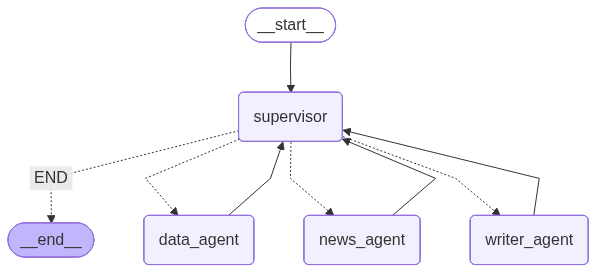

In [16]:
# Try to display the graph visually in the notebook
# Requires: pip install grandalf
try:
    from IPython.display import Image, display
    display(Image(app.get_graph().draw_mermaid_png()))
except Exception as e:
    # Fallback: print as Mermaid text (paste at https://mermaid.live to visualize)
    print("Graph visualization not available. Mermaid diagram:")
    print(app.get_graph().draw_mermaid())

## 🚀 Step 10 — Run the Pipeline!

This is the main execution cell. Change `COMPANY_NAME` to research any company.

In [24]:
# ============================================================
# 👇 CHANGE THIS to research any company!
# ============================================================
COMPANY_NAME = "Nvidia"
# Other options: "Apple", "Microsoft", "Nvidia", "Amazon", "Netflix"
# ============================================================

print(f"\n🔍 Starting Due Diligence for: {COMPANY_NAME}")
print("=" * 55)

# Initial state — the "starting whiteboard"
# Only company_name is filled in; agents will fill the rest
initial_state = {
    "company_name":    COMPANY_NAME,
    "next_agent":      "",      # Supervisor sets this on first run
    "financial_data":  None,    # Data Agent fills this
    "news_data":       None,    # News Agent fills this
    "investment_memo": None,    # Writer Agent fills this
    "messages": [
        {"role": "user",
         "content": f"Please perform financial due diligence on {COMPANY_NAME}."}
    ]
}

# Run the full multi-agent pipeline!
# LangGraph handles the loop: Supervisor → Agent → Supervisor → ... → END
print("\n⚡ Invoking multi-agent graph...\n")
final_state = app.invoke(initial_state)


🔍 Starting Due Diligence for: Nvidia

⚡ Invoking multi-agent graph...


-------------------------------------------------------
🎯 SUPERVISOR: Deciding next step...
   financial_data : ❌
   news_data      : ❌
   investment_memo: ❌
   Decision : → data_agent
   Reason   : No financial data yet

📊 DATA AGENT: Starting financial data collection...
   Company : Nvidia
   Ticker  : NVDA
   Fetching data from Yahoo Finance...
   Asking Groq LLM to analyze financial data...
   ✅ Data Agent complete!

-------------------------------------------------------
🎯 SUPERVISOR: Deciding next step...
   financial_data : ✅
   news_data      : ❌
   investment_memo: ❌
   Decision : → news_agent
   Reason   : Financial data ready, need news scan

📰 NEWS AGENT: Starting news scan and risk analysis...
   Company : Nvidia
   Searching web via Tavily...
      → Searching recent news...
      → Searching for red flags and risks...
   Found 5480 chars of raw news content
   Asking Groq LLM to analyze news for ri

## 📄 Step 11 — Display the Investment Memo

In [25]:
from IPython.display import Markdown, display

print("\n" + "🎉 " + "="*52)
print("   PIPELINE COMPLETE — FINAL INVESTMENT MEMO")
print("=" * 55 + "\n")

# Display the memo with Markdown rendering for nice formatting
memo = final_state.get("investment_memo", "❌ Error: No memo was generated.")
display(Markdown(memo))


🎉 ====================================================
   PIPELINE COMPLETE — FINAL INVESTMENT MEMO



**================================================**  
**INVESTMENT MEMO: NVIDIA**  
**Analyst: AI Due Diligence System**  
**================================================**  

---

### EXECUTIVE SUMMARY  
NVIDIA Corp. designs and sells GPU‑accelerated platforms for AI, data‑center, gaming, and automotive markets, operating primarily through its Compute & Networking and Graphics segments.  The company enjoys unparalleled profitability and rapid revenue growth driven by AI demand, but it trades at a premium valuation and carries an unusually high debt‑to‑equity ratio.  **Recommendation:** **BUY** for investors seeking exposure to the secular AI boom, provided they accept a medium‑level risk profile and are comfortable with the elevated multiples.

---

### COMPANY OVERVIEW  
| Item | Detail |
|------|--------|
| **Sector** | Semiconductors / Technology – AI‑driven compute |
| **Core Business Model** | Design of high‑performance GPUs and associated software ecosystems; monetization through hardware sales, licensing, and recurring data‑center services. |
| **Competitive Position** | Market‑leading GPU architecture (e.g., Hopper, Blackwell Ultra) with a dominant share in AI training/inference accelerators; strong network effects via CUDA ecosystem; entrenched relationships with hyperscale cloud providers and OEMs. |
| **Key Moat Drivers** | • Technological leadership & IP portfolio  <br>• Vast developer ecosystem (CUDA, cuDNN) <br>• Scale of manufacturing partnerships (TSMC) <br>• High barriers to entry in AI‑centric hardware |

---

### FINANCIAL ANALYSIS  

| Metric (FY 2025) | Value | Comment |
|------------------|-------|---------|
| **Revenue YoY** | +73.2 % | AI‑driven data‑center demand remains the primary growth engine. |
| **Net Income YoY** | +95.6 % | Margin expansion reflects pricing power and operating leverage. |
| **Gross Margin** | 71.1 % | Among the highest in the semiconductor industry, indicating pricing strength and efficient design. |
| **Net Profit Margin** | 55.6 % | Exceptional profitability for a capital‑intensive sector. |
| **ROE** | 101.5 % | Earnings vastly exceed equity base; driven by high leverage and cash generation. |
| **Cash & Cash Equivalents** | $62.6 bn | Large liquidity cushion. |
| **Total Debt** | $11.4 bn | Low absolute leverage, but **Debt‑to‑Equity = 7.26 (726 %)** – suggests equity base is modest relative to debt; a metric that warrants monitoring. |
| **Forward P/E** | 16.6× | Implies earnings acceleration expected by the market. |
| **Current P/E** | 36.2× | Significantly above sector average, reflecting a premium valuation. |
| **Price‑to‑Book** | 27.5× | High multiple, indicating market pricing of future growth rather than book value. |

**Strengths**  
* Industry‑leading margins and cash generation.  
* Strong balance sheet liquidity (cash > 5× total debt).  
* Rapid top‑line growth driven by AI adoption across cloud, enterprise, and automotive segments.  

**Concerns**  
* Valuation remains elevated relative to peers; any slowdown in AI spending could pressure multiples.  
* Debt‑to‑Equity ratio appears unusually high; while absolute debt is modest, the leverage metric could amplify downside if cash flows deteriorate.  
* Potential data inconsistency between market cap ($4.3 tn) and reported revenue ($215.9 bn) suggests the need for verification before large‑scale allocation.

---

### NEWS & RISK ASSESSMENT  

**Recent Developments**  
1. **Record‑size market cap** – Became the world’s most valuable public company in 2025, surpassing $4 tn.  
2. **Product Innovation** – Launched the **Blackwell Ultra GPU**, promising > 2× performance per watt over the previous generation.  
3. **Strategic Investment** – Committed $2 bn to **Synopsys**, deepening its foothold in EDA and expanding the software‑hardware integration pipeline.  

**Positive Signals**  
* Stock up **18 % YTD 2025** and **+182 % in 2024**, reflecting strong investor confidence.  
* Returned **$15.4 bn** to shareholders (share repurchases + dividends) in H1 FY 2025, underscoring capital‑return discipline.  

**Red Flags / Risks**  
| Risk | Impact | Mitigation |
|------|--------|------------|
| **Patent infringement lawsuit (2025)** | Potential settlement or injunctive relief could affect product timelines or incur damages. | Ongoing legal defense; historically successful in defending IP. |
| **Past securities‑fraud appeal (2024)** – Supreme Court dismissal, but litigation history may attract future scrutiny. | Reputation risk; possible regulatory follow‑up. | No ongoing enforcement actions; compliance program reinforced. |
| **Valuation pressure** | High forward P/E and P/B could compress if AI spend moderates. | Diversify revenue across gaming, automotive, and edge AI to cushion cyclical swings. |
| **Leverage metric** | Debt‑to‑Equity > 700 % could alarm risk‑averse investors. | Strong cash flow coverage; debt is manageable in absolute terms. |

**Overall Risk Level:** **Medium** – The company’s growth engine and balance sheet are robust, but valuation and legal exposures warrant close monitoring.

---

### INVESTMENT THESIS  

**Bull Case**  
* **AI secular tailwinds** – Continued expansion of generative AI, large‑language models, and AI‑enabled services will keep demand for high‑performance GPUs at a multi‑year high.  
* **Margin expansion & cash generation** – Ability to translate revenue growth into record‑high margins provides flexibility for reinvestment, share buybacks, and dividend growth.  
* **Moat reinforcement** – Blackwell Ultra and the CUDA ecosystem lock in customers, creating switching costs that are difficult for competitors to overcome.  
* **Strategic acquisitions** – Investment in Synopsys positions NVIDIA to capture more of the chip‑design value chain, potentially opening new recurring‑revenue streams.

**Bear Case**  
* **Valuation premium** – Current multiples leave little headroom for error; a modest slowdown in AI capex could trigger a sharp price correction.  
* **Legal headwinds** – Patent litigation could result in injunctions or royalty obligations that erode margins.  
* **Competitive escalation** – Rivals (AMD, Intel, and emerging Chinese GPU designers) are accelerating their AI‑focused product roadmaps, which could compress market share over the next 2‑3 years.  
* **Macroeconomic sensitivity** – Semiconductor cycles are historically volatile; a broader tech slowdown could impact both data‑center and gaming demand.

---

### RECOMMENDATION  

**BUY** – NVIDIA remains the premier play on the AI acceleration theme, delivering unmatched profitability and cash flow.  While the stock trades at a high valuation and carries medium‑level risk from legal and competitive fronts, the upside from sustained AI demand, product leadership, and strong balance sheet outweighs these concerns for a growth‑oriented portfolio.  Position size should be calibrated to the investor’s risk tolerance, with a stop‑loss framework to guard against valuation compression.  

---

**================================================**  
**DISCLAIMER:** This memo is AI‑generated for educational purposes only and does not constitute financial advice. Investors should conduct their own due diligence and consult professional advisors before making any investment decisions.  
**================================================**

## 📋 Step 12 — Pipeline Summary

In [26]:
print("\n" + "="*55)
print("📋 PIPELINE EXECUTION SUMMARY")
print("="*55)

# Print the message log to see what each agent did
for msg in final_state.get("messages", []):
    role    = msg.get("role", "unknown").upper()
    content = msg.get("content", "")
    print(f"  [{role}] {content}")

# Print state summary
print("\n" + "="*55)
print("📊 FINAL STATE SUMMARY")
print("="*55)
print(f"  company_name   : {final_state['company_name']}")
print(f"  financial_data : {len(final_state.get('financial_data','') or '')} chars")
print(f"  news_data      : {len(final_state.get('news_data','') or '')} chars")
print(f"  investment_memo: {len(final_state.get('investment_memo','') or '')} chars")
print(f"  next_agent     : {final_state.get('next_agent')} (END = success)")


📋 PIPELINE EXECUTION SUMMARY
  [USER] Please perform financial due diligence on Nvidia.
  [ASSISTANT] [Data Agent] Financial analysis complete for Nvidia.
  [ASSISTANT] [News Agent] Risk scan complete for Nvidia.
  [ASSISTANT] [Writer Agent] Investment memo generated for Nvidia.

📊 FINAL STATE SUMMARY
  company_name   : Nvidia
  financial_data : 1814 chars
  news_data      : 1564 chars
  investment_memo: 7372 chars
  next_agent     : END (END = success)


## 🧪 Step 13 — Inspect Individual Agent Outputs (Debug)

In [27]:
# Use this cell to inspect what each agent produced
# Useful for debugging or understanding the pipeline

print("=" * 55)
print("📊 DATA AGENT OUTPUT (Financial Analysis)")
print("=" * 55)
print(final_state.get("financial_data", "Not available"))

📊 DATA AGENT OUTPUT (Financial Analysis)
**1. Company Snapshot**  
NVIDIA Corporation is a U.S.–based technology firm focused on AI‑driven data‑center computing, networking, and graphics solutions. It operates two segments – Compute & Networking and Graphics – and is a market leader in GPU‑based acceleration for AI, gaming, and automotive applications. The company trades at a high valuation but delivers exceptionally strong profitability and growth.

**2. Key Financial Strengths**  
- **Profitability:** Gross margin 71.1% and net profit margin 55.6% – among the highest in the semiconductor industry.  
- **Return on Equity:** 101.5%, indicating that earnings vastly exceed the equity base.  
- **Revenue & Earnings Growth:** Revenue up 73.2% YoY; earnings up 95.6% YoY, reflecting rapid expansion of AI‑related demand.  
- **Liquidity:** $62.6 bn of cash on hand versus $11.4 bn total debt, giving a solid cash‑to‑debt cushion.  
- **Forward Valuation:** Forward P/E 16.6, well below the curre

In [28]:
print("=" * 55)
print("📰 NEWS AGENT OUTPUT (Risk Analysis)")
print("=" * 55)
print(final_state.get("news_data", "Not available"))

📰 NEWS AGENT OUTPUT (Risk Analysis)
**Recent Developments:**
1. Nvidia became the world's most valuable company in 2025, surpassing Microsoft and Apple, with a market cap reaching $4 trillion.
2. The company announced significant technological advancements, including the Blackwell Ultra GPU.
3. Nvidia invested $2 billion in Synopsys, a chip design software maker, expanding its presence in the industry.

**Red Flags:**
1. A patent infringement lawsuit against Nvidia was ongoing in 2025, posing a risk of potential settlements or damages.
2. Although the Supreme Court dismissed a securities fraud appeal against Nvidia in 2024, the company faced scrutiny over investor fraud lawsuits, which could impact corporate accountability.
No leadership issues, regulatory problems, or fraud cases were found, but the ongoing patent infringement lawsuit and past securities fraud appeals are notable.

**Positive Signals:**
1. Nvidia's stock price has risen significantly, with an 18% increase since the be

---

## 🎓 What You Learned

| Concept | Where in this notebook |
|---------|------------------------|
| Shared State (TypedDict) | Cell 3 — `AgentState` |
| Tools vs Agents distinction | Cells 4-5 (tools) vs Cells 6-8 (agents) |
| Rule-based Supervisor routing | Cell 9 |
| LangGraph nodes + edges | Cell 10 |
| Conditional edges | `add_conditional_edges` in Cell 10 |
| Worker → Supervisor loop | `add_edge` calls in Cell 10 |
| Temperature tuning | 0.0 for analysis, 0.3 for writing |
